Full Data cleaning of Kaggle sales data

In [ ]:
#import csv file
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#importing nessary libraries
import pandas as pd
import numpy as np
import os
import datetime
import matplotlib.pyplot as plt


In [ ]:
# Directory path where the CSV files are located
data_dir = '/content/drive/MyDrive/Pandas-Data-Science-Tasks-master (2)/Pandas-Data-Science-Tasks-master/Pandas-Data-Science-Tasks-master/SalesAnalysis/Sales_Data'

# List to hold individual dataframes
all_months_data = []

# Loop through each file in the directory
for filename in os.listdir(data_dir):
    if filename.endswith('.csv'):  # Check if the file is a CSV
        file_path = os.path.join(data_dir, filename)  # Construct full file path
        current_df = pd.read_csv(file_path)
        all_months_data.append(current_df)

# Concatenate all dataframes into one
df = pd.concat(all_months_data, ignore_index=True)
df.to_csv('All_sales_data.csv')

In [ ]:
#Making copy of the original dataset
clean_df=df.copy()

In [ ]:
#Quick Overview of the daatset
clean_df.tail(50)
clean_df.head(50)
clean_df.info()
clean_df.describe()
clean_df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 186850 entries, 0 to 186849
Data columns (total 6 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   Order ID          186305 non-null  object
 1   Product           186305 non-null  object
 2   Quantity Ordered  186305 non-null  object
 3   Price Each        186305 non-null  object
 4   Order Date        186305 non-null  object
 5   Purchase Address  186305 non-null  object
dtypes: object(6)
memory usage: 8.6+ MB


(186850, 6)

In [ ]:
#Finding Missing Values
clean_df.isna().sum()
clean_df.replace('NA',np.nan,inplace=True)
clean_df.dropna(axis='index',how='all',inplace=True)

clean_df['Price Each'].unique()

# Convert 'Price Each' to numeric, coercing errors (this turns 'Price Each' strings into NaN)
clean_df['Price Each'] = pd.to_numeric(clean_df['Price Each'], errors='coerce')
# Fill remaining NaNs in 'Price Each' with its median
price_each_median = clean_df['Price Each'].median()
clean_df['Price Each'] = clean_df['Price Each'].fillna(price_each_median)

clean_df['Quantity Ordered'].unique()

# Convert 'Quantity Ordered' to numeric, coercing errors (this turns 'Quantity Ordered' strings into NaN)
clean_df['Quantity Ordered'] = pd.to_numeric(clean_df['Quantity Ordered'], errors='coerce')
# Fill remaining NaNs in 'Quantity Ordered' with its mode
# .mode() returns a Series, so we take the first element (index 0) if multiple modes exist
quantity_ordered_mode = clean_df['Quantity Ordered'].mode()[0]
clean_df['Quantity Ordered'] = clean_df['Quantity Ordered'].fillna(quantity_ordered_mode)
clean_df


,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
0,248151,AA Batteries (4-pack),4.0,3.84,09/17/19 14:44,"380 North St, Los Angeles, CA 90001"
1,248152,USB-C Charging Cable,2.0,11.95,09/29/19 10:19,"511 8th St, Austin, TX 73301"
2,248153,USB-C Charging Cable,1.0,11.95,09/16/19 17:48,"151 Johnson St, Los Angeles, CA 90001"
3,248154,27in FHD Monitor,1.0,149.99,09/27/19 07:52,"355 Hickory St, Seattle, WA 98101"
4,248155,USB-C Charging Cable,1.0,11.95,09/01/19 19:03,"125 5th St, Atlanta, GA 30301"
...,...,...,...,...,...,...
186845,236665,Wired Headphones,1.0,11.99,07/20/19 16:16,"694 Meadow St, Atlanta, GA 30301"
186846,236666,20in Monitor,1.0,109.99,07/31/19 20:11,"866 14th St, San Francisco, CA 94016"
186847,236667,AAA Batteries (4-pack),1.0,2.99,07/17/19 22:29,"249 Cherry St, Dallas, TX 75001"
186848,236668,Wired Headphones,1.0,11.99,07/30/19 19:28,"727 Wilson St, Austin, TX 73301"


In [ ]:
#Treating Duplicate values
clean_df.duplicated().sum()
clean_df.drop_duplicates(inplace=True)
clean_df

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
0,248151,AA Batteries (4-pack),4.0,3.84,09/17/19 14:44,"380 North St, Los Angeles, CA 90001"
1,248152,USB-C Charging Cable,2.0,11.95,09/29/19 10:19,"511 8th St, Austin, TX 73301"
2,248153,USB-C Charging Cable,1.0,11.95,09/16/19 17:48,"151 Johnson St, Los Angeles, CA 90001"
3,248154,27in FHD Monitor,1.0,149.99,09/27/19 07:52,"355 Hickory St, Seattle, WA 98101"
4,248155,USB-C Charging Cable,1.0,11.95,09/01/19 19:03,"125 5th St, Atlanta, GA 30301"
...,...,...,...,...,...,...
186845,236665,Wired Headphones,1.0,11.99,07/20/19 16:16,"694 Meadow St, Atlanta, GA 30301"
186846,236666,20in Monitor,1.0,109.99,07/31/19 20:11,"866 14th St, San Francisco, CA 94016"
186847,236667,AAA Batteries (4-pack),1.0,2.99,07/17/19 22:29,"249 Cherry St, Dallas, TX 75001"
186848,236668,Wired Headphones,1.0,11.99,07/30/19 19:28,"727 Wilson St, Austin, TX 73301"


In [ ]:
#Treating the columns name
columns=clean_df.columns
new_columns=[x.replace(' ','_') for x in columns ]    #here x is a string
clean_df.columns=new_columns
clean_df

,Order_ID,Product,Quantity_Ordered,Price_Each,Order_Date,Purchase_Address
0,248151,AA Batteries (4-pack),4.0,3.84,09/17/19 14:44,"380 North St, Los Angeles, CA 90001"
1,248152,USB-C Charging Cable,2.0,11.95,09/29/19 10:19,"511 8th St, Austin, TX 73301"
2,248153,USB-C Charging Cable,1.0,11.95,09/16/19 17:48,"151 Johnson St, Los Angeles, CA 90001"
3,248154,27in FHD Monitor,1.0,149.99,09/27/19 07:52,"355 Hickory St, Seattle, WA 98101"
4,248155,USB-C Charging Cable,1.0,11.95,09/01/19 19:03,"125 5th St, Atlanta, GA 30301"
...,...,...,...,...,...,...
186845,236665,Wired Headphones,1.0,11.99,07/20/19 16:16,"694 Meadow St, Atlanta, GA 30301"
186846,236666,20in Monitor,1.0,109.99,07/31/19 20:11,"866 14th St, San Francisco, CA 94016"
186847,236667,AAA Batteries (4-pack),1.0,2.99,07/17/19 22:29,"249 Cherry St, Dallas, TX 75001"
186848,236668,Wired Headphones,1.0,11.99,07/30/19 19:28,"727 Wilson St, Austin, TX 73301"


In [ ]:
# Treating the data type of the columns
clean_df['Order_Date'] = pd.to_datetime(
    clean_df['Order_Date'], errors='coerce')
clean_df

/tmp/ipykernel_3789/1223226861.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  clean_df['Order_Date'] = pd.to_datetime(


,Order_ID,Product,Quantity_Ordered,Price_Each,Order_Date,Purchase_Address
0,248151,AA Batteries (4-pack),4.0,3.84,2019-09-17 14:44:00,"380 North St, Los Angeles, CA 90001"
1,248152,USB-C Charging Cable,2.0,11.95,2019-09-29 10:19:00,"511 8th St, Austin, TX 73301"
2,248153,USB-C Charging Cable,1.0,11.95,2019-09-16 17:48:00,"151 Johnson St, Los Angeles, CA 90001"
3,248154,27in FHD Monitor,1.0,149.99,2019-09-27 07:52:00,"355 Hickory St, Seattle, WA 98101"
4,248155,USB-C Charging Cable,1.0,11.95,2019-09-01 19:03:00,"125 5th St, Atlanta, GA 30301"
...,...,...,...,...,...,...
186845,236665,Wired Headphones,1.0,11.99,2019-07-20 16:16:00,"694 Meadow St, Atlanta, GA 30301"
186846,236666,20in Monitor,1.0,109.99,2019-07-31 20:11:00,"866 14th St, San Francisco, CA 94016"
186847,236667,AAA Batteries (4-pack),1.0,2.99,2019-07-17 22:29:00,"249 Cherry St, Dallas, TX 75001"
186848,236668,Wired Headphones,1.0,11.99,2019-07-30 19:28:00,"727 Wilson St, Austin, TX 73301"


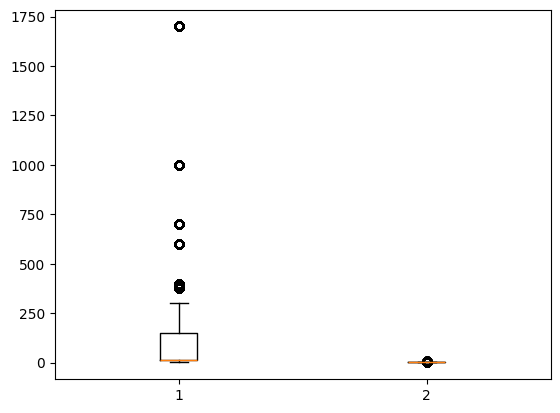

,Product,Quantity_Ordered,Price_Each
43316,AAA Batteries (4-pack),9.0,2.99
176219,AAA Batteries (4-pack),9.0,2.99
176855,AAA Batteries (4-pack),9.0,2.99


In [ ]:
#handle outliers

#step1: Getting rough figure
clean_df.describe()
#step2: Getting into the columns
clean_df['Price_Each'].value_counts()
# step3: Getting the plot view of outliars
plt.boxplot(clean_df[['Price_Each','Quantity_Ordered']])
plt.show()
#step4: seeing the outliars in different rows and analising it

def find_outliers(df, column):
    Q1 = clean_df['Price_Each'].quantile(0.25)
    Q3 = clean_df['Price_Each'].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = clean_df[
        (clean_df['Price_Each'] < lower) |
        (clean_df['Price_Each'] > upper)]

    return outliers

#Use on any numeric column
df1=find_outliers(clean_df, 'Price_Each')

filt=df1['Price_Each']>1000
df1.loc[filt,['Product','Price_Each']]
#conclusion no invalid outlairs ,all are resonable
#similarly with other columns

filt=clean_df['Quantity_Ordered']>8
clean_df.loc[filt,['Product','Quantity_Ordered','Price_Each']]

In [ ]:
#Treating inconsitent or absurt values
# clean_df.reset_index('Product',inplace=True)
# clean_df = clean_df.dropna(subset=['Order_Date'])
clean_df[clean_df['Product']=='Product']
# clean_df.loc['Product']
# df['Product'].value_counts()
# clean_df


,Order_ID,Product,Quantity_Ordered,Price_Each,Order_Date,Purchase_Address
1679,Order ID,Product,1.0,14.95,NaT,Purchase Address


In [ ]:
#To save the as Cleaned csv file
clean_df.to_csv('cleaned.csv', index=False)